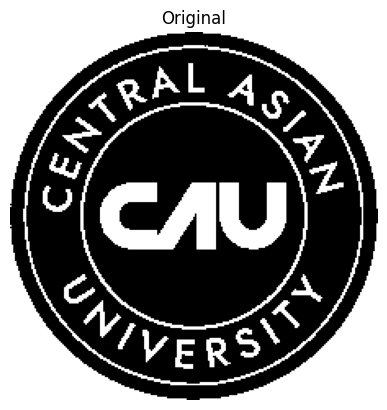

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/cau.webp", 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)



plt.figure(figsize=(12,8))
plt.subplot(231), plt.imshow(binary, cmap='gray'), plt.title("Original"), plt.axis("off")

plt.tight_layout()
plt.show()

1 Hit-or-Miss

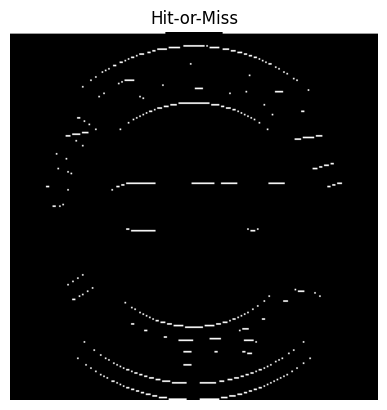

In [9]:
binary01 = (binary // 255).astype(np.uint8)
kernel = np.array([[-1,-1,-1],
                   [ 0, 1, 0],
                   [ 1, 1, 1]], dtype=np.int8)
hitmiss = cv2.morphologyEx(binary01, cv2.MORPH_HITMISS, kernel) * 255

plt.figure(figsize=(12,8))
plt.subplot(232), plt.imshow(hitmiss, cmap='gray'), plt.title("Hit-or-Miss"), plt.axis("off")

plt.tight_layout()
plt.show()

2 Boundary Extraction

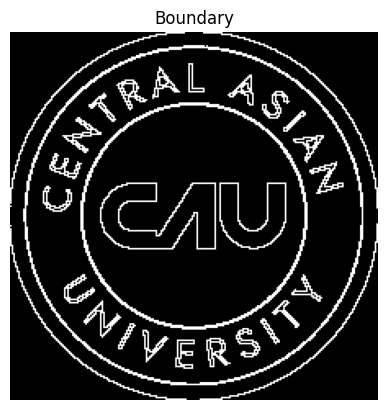

In [10]:
se = np.ones((3,3), np.uint8)
boundary = cv2.subtract(binary, cv2.erode(binary, se))
plt.figure(figsize=(12,8))
plt.subplot(233), plt.imshow(boundary, cmap='gray'), plt.title("Boundary"), plt.axis("off")
plt.tight_layout()
plt.show()

3 Hole Filling

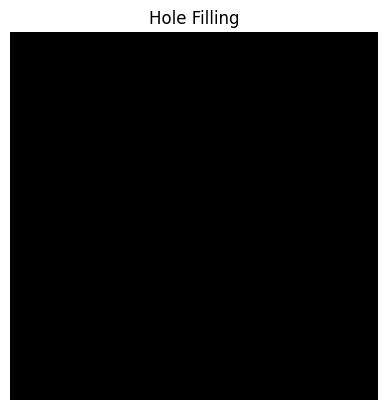

In [21]:
mask = np.zeros((binary.shape[0]+2, binary.shape[1]+2), np.uint8)
flood = binary.copy()
cv2.floodFill(flood, mask, (0,0), 255)
holes = cv2.bitwise_not(flood)
filled = cv2.bitwise_or(binary, holes)

plt.figure(figsize=(12,8))
plt.subplot(234), plt.imshow(filled, cmap='gray'), plt.title("Hole Filling"), plt.axis("off")

plt.tight_layout()
plt.show()

4 Connected Components

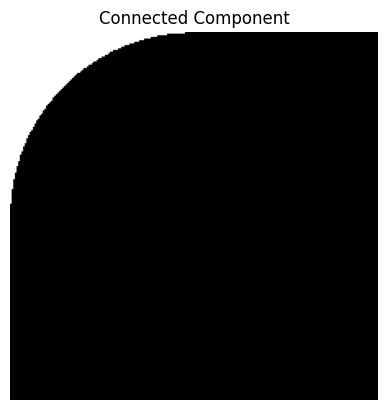

In [14]:
num_labels, labels = cv2.connectedComponents(binary)
component = np.zeros_like(binary)
if num_labels > 1:
    component[labels == 1] = 255

plt.figure(figsize=(12,8))
plt.subplot(235), plt.imshow(component, cmap='gray'), plt.title("Connected Component"), plt.axis("off")

plt.tight_layout()
plt.show()